<a href="https://colab.research.google.com/github/ShahJahanBrohii/ML-Internship-Flyrank/blob/main/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

This playbook ranks `keyword article` pages for human review. The final score combines the validated model probability with a transparent rule score: 70% model signal and 30% normalized visibility/freshness/position/depth signals. Reason codes explain why a row is present; they are prompts for review, not automatic instructions.

Archetype-to-action mapping:

| Archetype | Evidence pattern | Suggested action |
|---|---|---|
| `thin_visible` | Visible page with low word count | `expand_and_refresh` |
| `ctr_gap` | Visible page, page-one position, low CTR, decline risk | `refresh_and_review_ctr` |
| `engagement_gap` | Meaningful sessions with low engagement/scroll signal and decline risk | `refresh_and_review_engagement` |
| `stale_visible` | Stale, visible, or model-ranked decline opportunity | `refresh` |
| `monitor` | No sufficiently specific review signal | `monitor` |

The action is a ranked recommendation for editorial triage. A person still checks the page, intent, measurement window, and business context.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

RANDOM_STATE = 42
DATA_CANDIDATES = [
    Path("/content/content_refresh_anonymized.csv"),
    Path("data/raw/content_refresh_anonymized.csv"),
    Path("/content/flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv"),
]
data_path = next((path for path in DATA_CANDIDATES if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find data/raw/content_refresh_anonymized.csv")

data = pd.read_csv(data_path)
lane = data.loc[data["content_type"].eq("keyword article")].copy()
lane["is_declining_label"] = lane["trend_direction"].astype(str).str.lower().eq("down").astype(int)

feature_columns = [
    "days_since_last_update", "content_age_days", "word_count", "char_count",
    "search_volume", "competition", "cpc", "impressions_90d", "clicks_90d",
    "pageviews_90d", "sessions_90d", "users_90d", "engaged_sessions_90d",
    "ai_sessions_90d", "scroll_events_90d", "days_with_impressions", "days_with_sessions",
    "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",
    "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d", "ctr",
    "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct",
]
feature_columns = [column for column in feature_columns if column in lane.columns]
X = lane[feature_columns].apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
y = lane["is_declining_label"].astype(int)

forbidden_features = {"content_id", "client_id", "trend_direction", "trend_pct", "is_declining_label"}
assert not forbidden_features.intersection(feature_columns)
assert y.nunique() == 2

def percentile_rank(series):
    return pd.to_numeric(series, errors="coerce").fillna(0).rank(method="average", pct=True)


def normalize(series):
    values = pd.to_numeric(series, errors="coerce").fillna(0)
    span = values.max() - values.min()
    return pd.Series(0.0, index=values.index) if span == 0 else (values - values.min()) / span


def precision_at_k(labels, scores, k=50):
    ranked = pd.DataFrame({"label": np.asarray(labels), "score": np.asarray(scores)})
    return float(ranked.sort_values("score", ascending=False).head(k)["label"].mean())

# Client-held-out receipt, matching the Week-6 honest validation design.
clients = lane["client_id"].fillna("unknown").astype(str)
rng = np.random.default_rng(RANDOM_STATE)
shuffled_clients = rng.permutation(clients.drop_duplicates().to_numpy())
test_clients = set(shuffled_clients[:max(1, int(round(len(shuffled_clients) * 0.20)))])
test_mask = clients.isin(test_clients).to_numpy()
train_indices = np.flatnonzero(~test_mask)
test_indices = np.flatnonzero(test_mask)
validation_model = RandomForestClassifier(
    class_weight="balanced_subsample", max_depth=10, min_samples_leaf=25,
    n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE,
)
validation_model.fit(X.iloc[train_indices], y.iloc[train_indices])
validation_scores = validation_model.predict_proba(X.iloc[test_indices])[:, 1]
validation_labels = y.iloc[test_indices].to_numpy()
validation_metrics = {
    "split": "client_holdout",
    "seed": RANDOM_STATE,
    "test_rows": int(len(test_indices)),
    "test_clients": int(len(test_clients)),
    "base_rate": float(validation_labels.mean()),
    "roc_auc": float(roc_auc_score(validation_labels, validation_scores)),
    "average_precision": float(average_precision_score(validation_labels, validation_scores)),
    "precision_at_50": precision_at_k(validation_labels, validation_scores),
}

# Retrain on the complete lane only after the validation receipt is measured.
model = RandomForestClassifier(
    class_weight="balanced_subsample", max_depth=10, min_samples_leaf=25,
    n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE,
)
model.fit(X, y)
lane["best_model_probability"] = model.predict_proba(X)[:, 1]

lane["visibility_score"] = percentile_rank(np.log1p(lane["impressions_90d"]))
lane["freshness_risk_score"] = percentile_rank(lane["days_since_last_update"])
lane["position_opportunity_score"] = (
    (1 - normalize(lane["avg_position"].clip(lower=1, upper=50)))
    * lane["visibility_score"]
    * (lane["avg_position"] > 0).astype(int)
)
lane["depth_gap_score"] = (1 - percentile_rank(lane["word_count"])) * lane["visibility_score"]
lane["baseline_refresh_score"] = (
    0.40 * lane["visibility_score"]
    + 0.30 * lane["freshness_risk_score"]
    + 0.25 * lane["position_opportunity_score"]
    + 0.05 * lane["depth_gap_score"]
).clip(0, 1)
lane["baseline_score_normalized"] = normalize(lane["baseline_refresh_score"])
lane["final_refresh_score"] = (
    100 * (0.70 * lane["best_model_probability"] + 0.30 * lane["baseline_score_normalized"])
).clip(0, 100)

# Evidence codes are deliberately readable and inspectable.
def reason_codes(row):
    reasons = []
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        reasons.append("stale_visible_page")
    if row["is_declining_label"] == 1 and row["impressions_90d"] >= 100:
        reasons.append("declining_with_demand")
    if 0 < row["word_count"] < 1200 and row["impressions_90d"] >= 250:
        reasons.append("thin_visible_page")
    if row["best_model_probability"] >= 0.65:
        reasons.append("model_decline_risk")
    if row["best_model_probability"] >= 0.50 and row["impressions_90d"] >= 500:
        reasons.append("visible_model_opportunity")
    if row["impressions_90d"] >= 500 and 0 < row["avg_position"] <= 20 and row["ctr"] < 0.5:
        reasons.append("ctr_review_candidate")
    if row["sessions_90d"] >= 30 and (
        (0 < row["engagement_rate"] < 30) or (0 < row["scroll_rate"] < 30)
    ):
        reasons.append("engagement_review_candidate")
    return "|".join(dict.fromkeys(reasons or ["general_refresh_review"]))

lane["reason_codes"] = lane.apply(reason_codes, axis=1)

def archetype(row):
    reasons = set(row["reason_codes"].split("|"))
    if "thin_visible_page" in reasons:
        return "thin_visible"
    if "ctr_review_candidate" in reasons and "model_decline_risk" in reasons:
        return "ctr_gap"
    if "engagement_review_candidate" in reasons and "model_decline_risk" in reasons:
        return "engagement_gap"
    if {"stale_visible_page", "model_decline_risk", "visible_model_opportunity"}.intersection(reasons):
        return "stale_visible"
    return "monitor"

lane["archetype"] = lane.apply(archetype, axis=1)

def suggested_action(row):
    reasons = set(row["reason_codes"].split("|"))
    if row["archetype"] == "thin_visible":
        return "expand_and_refresh"
    if row["archetype"] == "ctr_gap":
        return "refresh_and_review_ctr"
    if row["archetype"] == "engagement_gap":
        return "refresh_and_review_engagement"
    if row["archetype"] == "stale_visible":
        return "refresh"
    return "monitor"

lane["suggested_action"] = lane.apply(suggested_action, axis=1)
high_threshold = float(lane["final_refresh_score"].quantile(0.80))
medium_threshold = float(lane["final_refresh_score"].quantile(0.50))
lane["confidence"] = np.select(
    [
        (lane["final_refresh_score"] >= high_threshold) & (lane["impressions_90d"] >= 500) & (lane["best_model_probability"] >= 0.50),
        lane["final_refresh_score"] >= medium_threshold,
    ],
    ["high", "medium"],
    default="low",
)
lane = lane.sort_values(["final_refresh_score", "impressions_90d", "sessions_90d"], ascending=False).reset_index(drop=True)
lane["final_rank"] = lane.index + 1

queue_columns = [
    "final_rank", "content_id", "client_id", "final_refresh_score", "best_model_probability",
    "baseline_refresh_score", "confidence", "archetype", "suggested_action", "reason_codes",
    "is_declining_label", "impressions_90d", "clicks_90d", "sessions_90d", "avg_position",
    "ctr", "content_age_days", "days_since_last_update", "word_count", "trend_direction",
    "content_type", "main_intent",
]
queue = lane[[column for column in queue_columns if column in lane.columns]].copy()
print(f"Scored {len(queue):,} keyword-article rows with a client-held-out validation receipt.")
print(f"Validation Precision@50: {validation_metrics['precision_at_50']:.3f}; base rate: {validation_metrics['base_rate']:.3f}")
print("Top queue rows are displayed without identifiers:")
display(queue.drop(columns=["content_id", "client_id"], errors="ignore").head(10))

Scored 27,207 keyword-article rows with a client-held-out validation receipt.
Validation Precision@50: 1.000; base rate: 0.460
Top queue rows are displayed without identifiers:


,final_rank,final_refresh_score,best_model_probability,baseline_refresh_score,confidence,archetype,suggested_action,reason_codes,is_declining_label,impressions_90d,clicks_90d,sessions_90d,avg_position,ctr,content_age_days,days_since_last_update,word_count,trend_direction,content_type,main_intent
0,1,90.653011,0.897273,0.870295,high,engagement_gap,refresh_and_review_engagement,declining_with_demand|model_decline_risk|visib...,1,12029,121,119,5.8,1.01,106,106,2841.0,down,keyword article,informational
1,2,89.847430,0.908388,0.821176,high,engagement_gap,refresh_and_review_engagement,stale_visible_page|declining_with_demand|model...,1,25715,60,80,22.2,0.23,231,194,3861.0,down,keyword article,informational
2,3,87.755833,0.834089,0.917617,high,engagement_gap,refresh_and_review_engagement,declining_with_demand|model_decline_risk|visib...,1,28000,369,345,4.7,1.32,106,106,2902.0,down,keyword article,informational
3,4,87.458479,0.954666,0.646601,high,ctr_gap,refresh_and_review_ctr,declining_with_demand|model_decline_risk|visib...,1,21533,102,86,14.6,0.47,224,20,3709.0,down,keyword article,informational
4,5,87.014138,0.944307,0.655310,high,engagement_gap,refresh_and_review_engagement,declining_with_demand|model_decline_risk|visib...,1,25485,133,133,13.8,0.52,147,20,4098.0,down,keyword article,informational
5,6,86.950129,0.830097,0.901294,high,ctr_gap,refresh_and_review_ctr,declining_with_demand|model_decline_risk|visib...,1,43650,61,69,0.7,0.14,126,104,2946.0,down,keyword article,transactional
6,7,86.669896,0.922976,0.690946,high,ctr_gap,refresh_and_review_ctr,declining_with_demand|model_decline_risk|visib...,1,43216,128,134,9.6,0.30,224,20,4454.0,down,keyword article,informational
7,8,86.245987,0.909028,0.708080,high,ctr_gap,refresh_and_review_ctr,declining_with_demand|model_decline_risk|visib...,1,35224,99,118,5.2,0.28,224,20,4233.0,down,keyword article,informational
8,9,86.231482,0.908319,0.709171,high,ctr_gap,refresh_and_review_ctr,declining_with_demand|model_decline_risk|visib...,1,36929,54,69,5.6,0.15,224,20,3799.0,down,keyword article,informational
9,10,86.022473,0.838385,0.854526,high,engagement_gap,refresh_and_review_engagement,declining_with_demand|model_decline_risk|visib...,1,9594,72,89,5.1,0.75,106,106,2930.0,down,keyword article,informational


## 2. Intended use and limits

The intended user is an editor or analyst deciding which existing pages to inspect first. The queue is a prioritization aid: it makes observed signals easier to scan, groups pages into review archetypes, and preserves reason codes for a human discussion.

The decay/refresh view compares observed decline rates and queue scores across freshness bands. A higher-risk or higher-score older band would support a directional refresh-review hypothesis, not a causal conclusion that updating a page will improve it.

Limits are material. This is a 30,000-row anonymized starter slice, not the full warehouse. The label is an observed decline proxy, not a later refresh outcome, and the trailing metrics may overlap with how the label was formed. The score is not calibrated evidence that editing a page will improve performance. It should not be used to publish, delete, merge, or rewrite content without review.

In [2]:
action_summary = (
    queue.groupby(["archetype", "suggested_action"], dropna=False)
    .agg(rows=("final_rank", "size"), median_score=("final_refresh_score", "median"), decline_rate=("is_declining_label", "mean"))
    .reset_index()
)
display(action_summary.round(3))

cost_value = pd.DataFrame({
    "successful_review_value_units": [5, 10, 20],
    "review_cost_units": [1, 1, 1],
})
cost_value["break_even_success_rate"] = cost_value["review_cost_units"] / cost_value["successful_review_value_units"]
print("Illustrative cost/value sensitivity; replace units with local editorial estimates before use:")
display(cost_value)
print("The table is a decision aid, not an estimated return: this notebook does not observe causal refresh value.")

,archetype,suggested_action,rows,median_score,decline_rate
0,ctr_gap,refresh_and_review_ctr,3642,68.707,0.959
1,engagement_gap,refresh_and_review_engagement,1102,70.746,0.962
2,monitor,monitor,13068,41.685,0.225
3,stale_visible,refresh,9343,60.467,0.828
4,thin_visible,expand_and_refresh,52,48.709,0.481


Illustrative cost/value sensitivity; replace units with local editorial estimates before use:


,successful_review_value_units,review_cost_units,break_even_success_rate
0,5,1,0.20
1,10,1,0.10
2,20,1,0.05


The table is a decision aid, not an estimated return: this notebook does not observe causal refresh value.


## 3. Human review + the no-go list

Before acting, a reviewer checks: (1) the page still matches the intended query and audience, (2) the observed metrics are recent and complete enough, (3) the reason code is understandable, (4) the recommendation does not conflict with editorial, legal, accessibility, or brand requirements, and (5) the proposed change is reversible and measurable.

**No-go list:** do not automate publishing, deletion, canonical changes, redirects, merging pages, medical/legal/financial claims, or any action that changes a public page without approval. Do not treat a high score as a guarantee, use pseudonymous IDs to infer client identity, or use the observed decline label as evidence that a refresh caused an outcome. Low-volume, missing-data, or conflicting-signal rows should be sent to `monitor` or manual investigation.

In [3]:
review_rules = pd.DataFrame([
    {"rule": "manual_page_and_intent_check", "required": True, "reason": "A score cannot verify content quality or search intent."},
    {"rule": "verify_metric_window_and_missingness", "required": True, "reason": "Zeros and missing fields can reflect measurement availability."},
    {"rule": "approve_public_change", "required": True, "reason": "Publishing and deletion remain human decisions."},
    {"rule": "route_low_volume_or_conflicting_rows_to_monitor", "required": True, "reason": "Weak evidence should not trigger a confident action."},
])
display(review_rules)
no_go_actions = {"publish_automatically", "delete_automatically", "merge_automatically", "redirect_automatically"}
assert no_go_actions.isdisjoint(set(queue["suggested_action"].unique()))
assert set(queue["suggested_action"].unique()) <= {
    "expand_and_refresh", "refresh_and_review_ctr", "refresh_and_review_engagement", "refresh", "monitor"
}
print("No-go check passed: the queue contains review recommendations only, not irreversible production actions.")

,rule,required,reason
0,manual_page_and_intent_check,True,A score cannot verify content quality or searc...
1,verify_metric_window_and_missingness,True,Zeros and missing fields can reflect measureme...
2,approve_public_change,True,Publishing and deletion remain human decisions.
3,route_low_volume_or_conflicting_rows_to_monitor,True,Weak evidence should not trigger a confident a...


No-go check passed: the queue contains review recommendations only, not irreversible production actions.


## 4. Monitoring / retrain triggers

Monitor the playbook as decision support, not only as a model artifact. Recheck monthly or after a material data-pipeline change. Retrain or revisit the design when measured ranking quality on a fresh, client-grouped sample drops, the action mix changes sharply, input distributions drift, missingness rises, or reviewers repeatedly reject the same reason code.

Suggested triggers are deliberately conservative: review if `Precision@50` falls below the validation receipt by 0.10, if the declining-label base rate shifts by more than 0.10 absolute, if any core feature's missingness rises by 0.10, or if a new content type enters the queue. A trigger starts an investigation; it does not automatically retrain or publish.

In [4]:
monitoring_triggers = {
    "precision_at_50_floor": {"rule": "fresh grouped Precision@50 < validation Precision@50 - 0.10", "response": "inspect errors and refresh validation"},
    "base_rate_shift": {"rule": "absolute label-rate shift > 0.10", "response": "check population and label definition"},
    "missingness_shift": {"rule": "core-feature missingness rises > 0.10", "response": "investigate pipeline availability before scoring"},
    "action_mix_shift": {"rule": "new content type or material action-volume change", "response": "pause broad rollout and review segments"},
    "reviewer_disagreement": {"rule": "repeated rejection of a reason code", "response": "audit the reason and retrain only after review"},
}
print(json.dumps(monitoring_triggers, indent=2))
assert len(monitoring_triggers) == 5
print("Monitoring triggers are review thresholds, not automatic production controls.")

{
  "precision_at_50_floor": {
    "rule": "fresh grouped Precision@50 < validation Precision@50 - 0.10",
    "response": "inspect errors and refresh validation"
  },
  "base_rate_shift": {
    "rule": "absolute label-rate shift > 0.10",
    "response": "check population and label definition"
  },
  "missingness_shift": {
    "rule": "core-feature missingness rises > 0.10",
    "response": "investigate pipeline availability before scoring"
  },
  "action_mix_shift": {
    "rule": "new content type or material action-volume change",
    "response": "pause broad rollout and review segments"
  },
  "reviewer_disagreement": {
    "rule": "repeated rejection of a reason code",
    "response": "audit the reason and retrain only after review"
  }
}
Monitoring triggers are review thresholds, not automatic production controls.


## 5. Exports for the paper

The queue CSV is regenerated by the notebook and stays out of git because it contains row-level data. The metrics JSON is a committed receipt for the paper's numbers. Figures are written to `work/figures/` for reuse in the recommendations section.

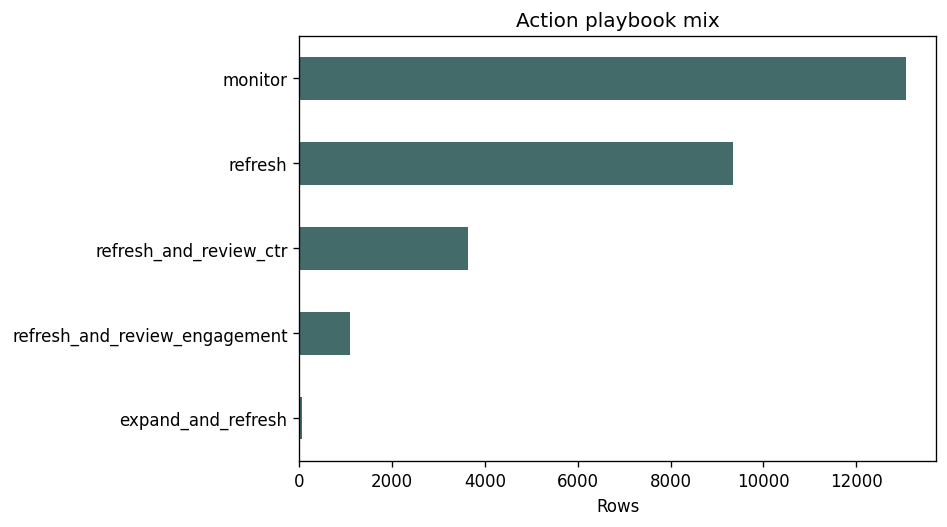

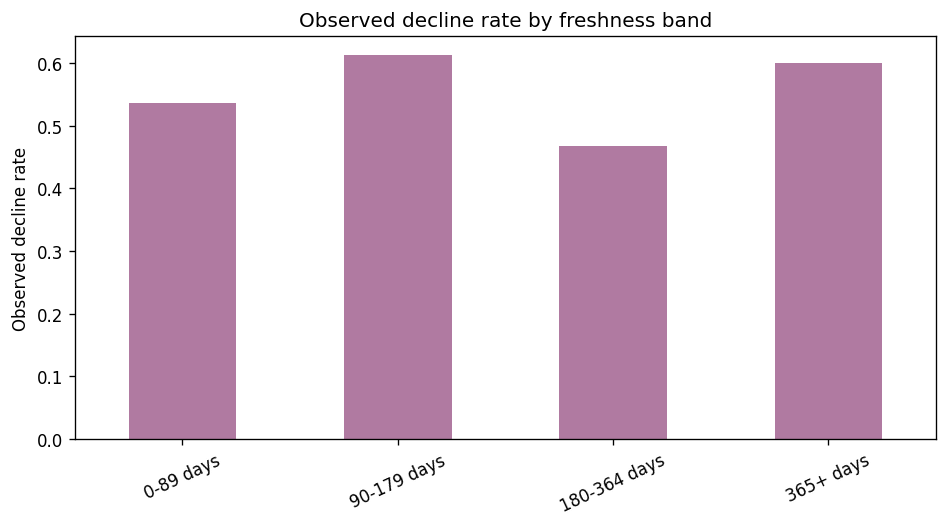

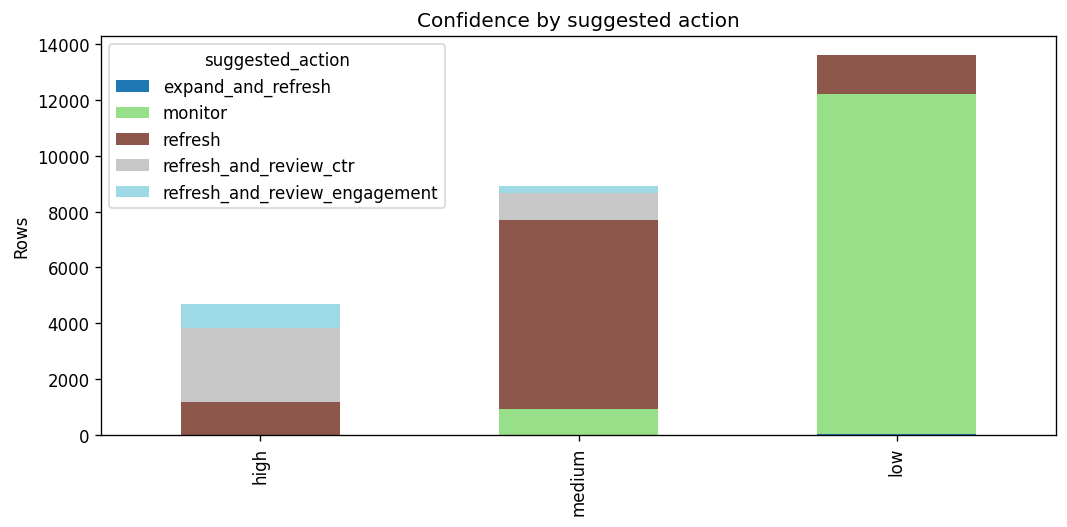

Wrote queue: work/outputs/action_playbook_queue.csv
Wrote metrics receipt: work/outputs/action_playbook_metrics.json
Wrote figures: work/figures


In [5]:
output_dir = Path("work/outputs")
figure_dir = Path("work/figures")
output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

queue_path = output_dir / "action_playbook_queue.csv"
metrics_path = output_dir / "action_playbook_metrics.json"
queue.to_csv(queue_path, index=False)

# Reusable, deliberately simple figures for the paper.
plt.rcParams["figure.dpi"] = 120
fig, ax = plt.subplots(figsize=(8, 4.5))
queue["suggested_action"].value_counts().sort_values().plot.barh(ax=ax, color="#426B69")
ax.set_title("Action playbook mix")
ax.set_xlabel("Rows")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(figure_dir / "action_playbook_mix.png")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 4.5))
decay_bins = [0, 90, 180, 365, np.inf]
decay_labels = ["0-89 days", "90-179 days", "180-364 days", "365+ days"]
lane["freshness_band"] = pd.cut(lane["days_since_last_update"], bins=decay_bins, labels=decay_labels, right=False)
decay_table = lane.groupby("freshness_band", observed=False).agg(
    rows=("final_rank", "size"), observed_decline_rate=("is_declining_label", "mean"), median_score=("final_refresh_score", "median")
).reset_index()
decay_table.plot(x="freshness_band", y="observed_decline_rate", kind="bar", ax=ax, color="#B07AA1", legend=False)
ax.set_title("Observed decline rate by freshness band")
ax.set_xlabel("")
ax.set_ylabel("Observed decline rate")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(figure_dir / "decay_refresh_insight.png")
plt.show()
plt.close(fig)

action_confidence = pd.crosstab(queue["confidence"], queue["suggested_action"]).reindex(["high", "medium", "low"], fill_value=0)
action_confidence.plot(kind="bar", stacked=True, figsize=(9, 4.5), colormap="tab20")
plt.title("Confidence by suggested action")
plt.xlabel("")
plt.ylabel("Rows")
plt.tight_layout()
plt.savefig(figure_dir / "confidence_by_action.png")
plt.show()
plt.close()

metrics_receipt = {
    "rows_scored": int(len(queue)),
    "target": "is_declining_label",
    "target_positive_rate": float(y.mean()),
    "validation": validation_metrics,
    "model": {"name": "random_forest", "random_state": RANDOM_STATE, "score_formula": "0.70 * model_probability + 0.30 * normalized_rule_score"},
    "thresholds": {"high_confidence_score": high_threshold, "medium_confidence_score": medium_threshold},
    "action_counts": {str(key): int(value) for key, value in queue["suggested_action"].value_counts().items()},
    "archetype_counts": {str(key): int(value) for key, value in queue["archetype"].value_counts().items()},
    "decay_table": decay_table.to_dict(orient="records"),
    "queue_output": str(queue_path).replace("\\", "/"),
    "figures": [
        "work/figures/action_playbook_mix.png",
        "work/figures/decay_refresh_insight.png",
        "work/figures/confidence_by_action.png",
    ],
}
metrics_path.write_text(json.dumps(metrics_receipt, indent=2, default=str))
print(f"Wrote queue: {queue_path}")
print(f"Wrote metrics receipt: {metrics_path}")
print(f"Wrote figures: {figure_dir}")
assert queue_path.exists() and metrics_path.exists()
assert all((figure_dir / name).exists() for name in ["action_playbook_mix.png", "decay_refresh_insight.png", "confidence_by_action.png"])

## Self-check

- [x] Ranked queue has readable reason codes, archetypes, confidence, and suggested actions.
- [x] Intended use, limits, decay/refresh interpretation, cost/value thinking, and human review are stated.
- [x] No-go cases explicitly exclude irreversible or unsupervised production actions.
- [x] Monitoring and retrain triggers are concrete and do not imply automatic retraining.
- [x] Notebook exports the queue, metrics receipt, and reusable figures to the required paths.
- [x] Claims are observed, measured, directional, and decision-support only.
- [ ] Run every cell top to bottom in Colab, inspect the exports, and commit the notebook plus metrics JSON and figures.